In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [2]:
name = "Mrk421"
blazar_coord = SkyCoord.from_name(name)
data_folder = "../cta_dc_data/mrk_421/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 118


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 16.2h


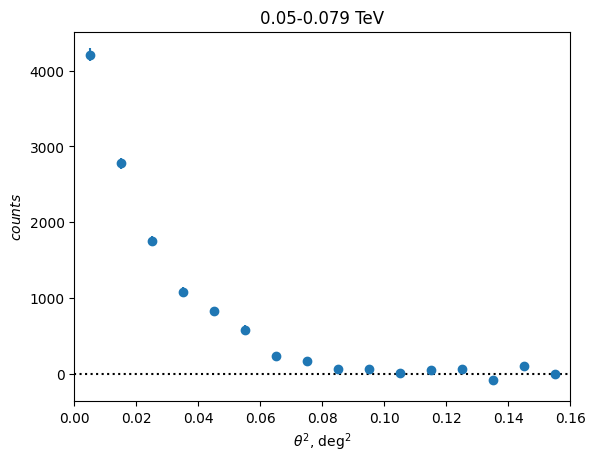

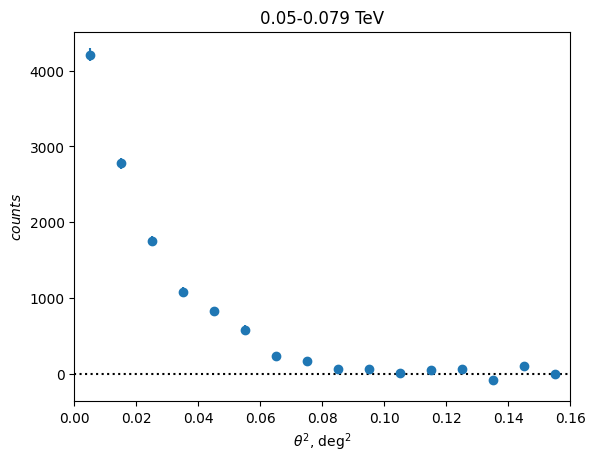

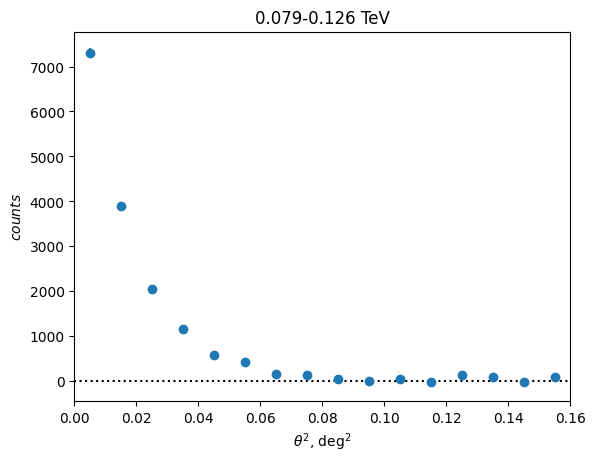

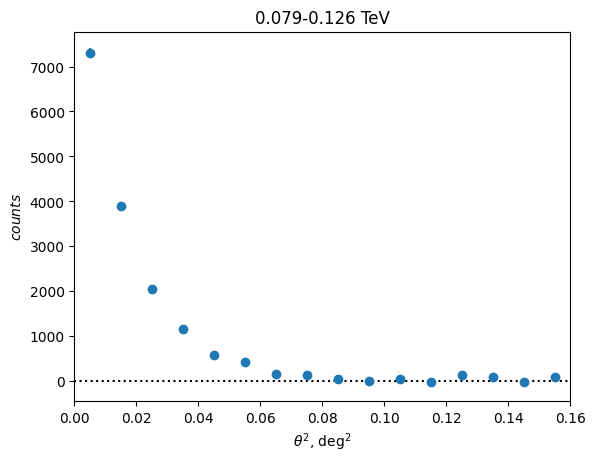

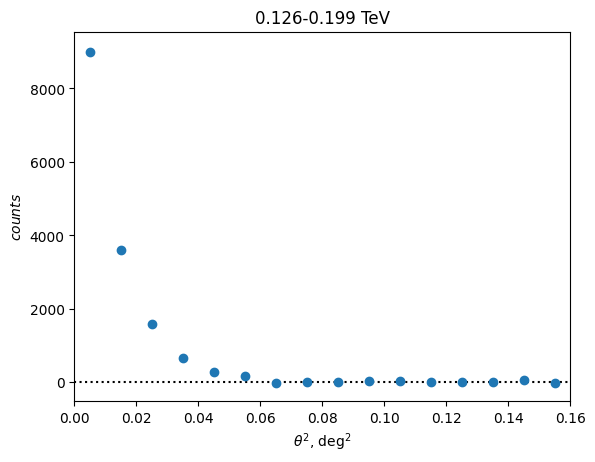

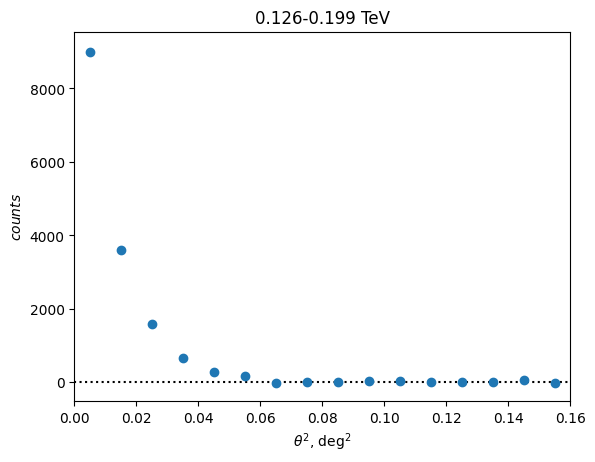

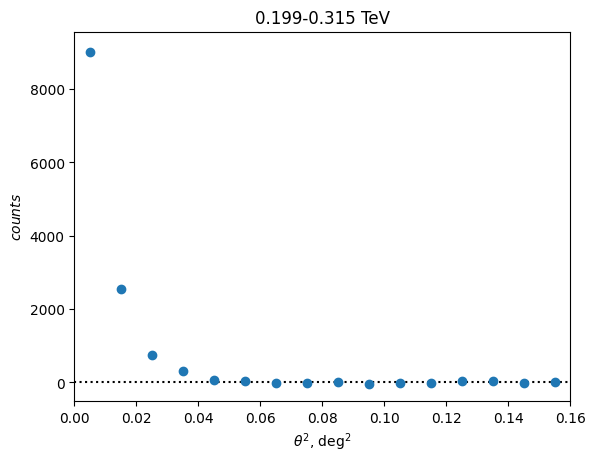

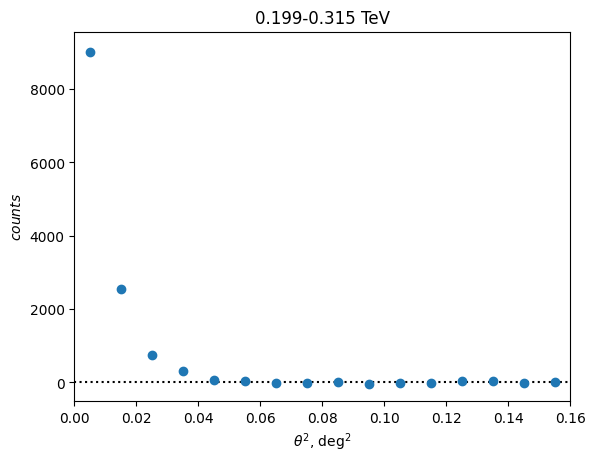

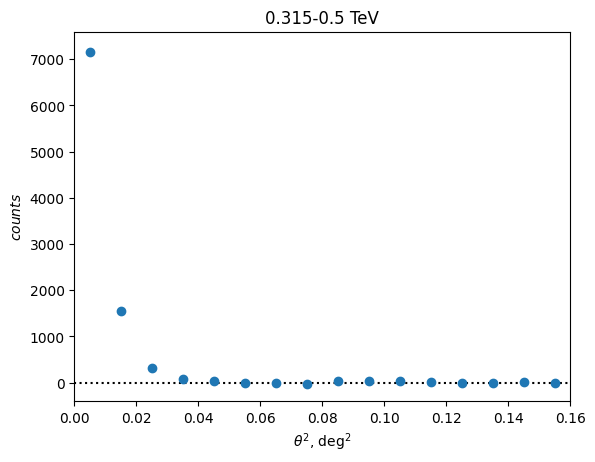

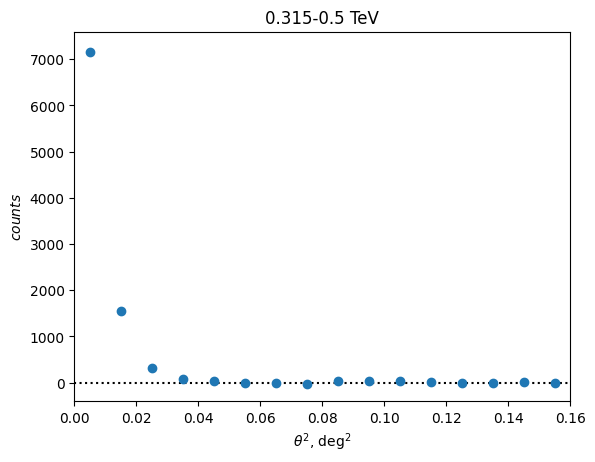

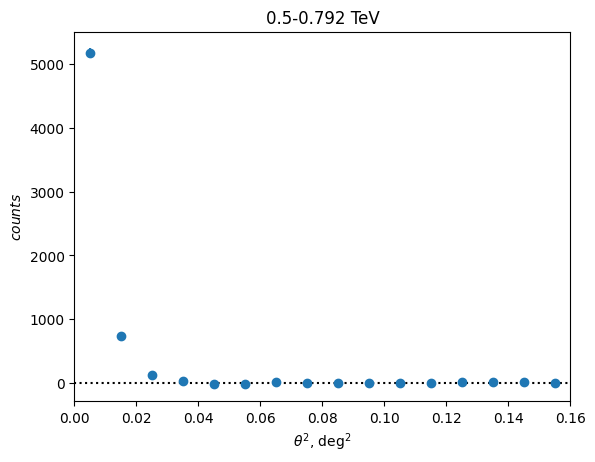

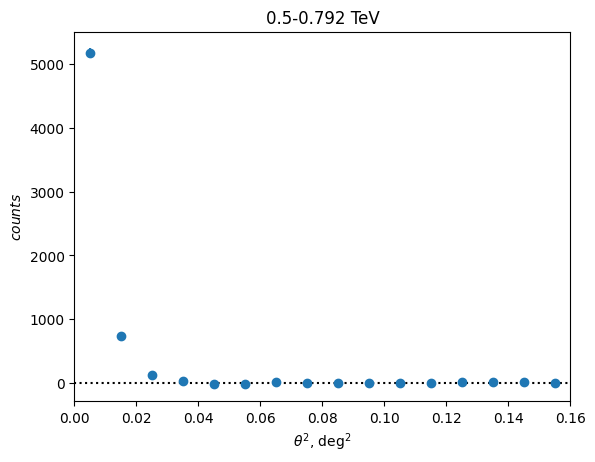

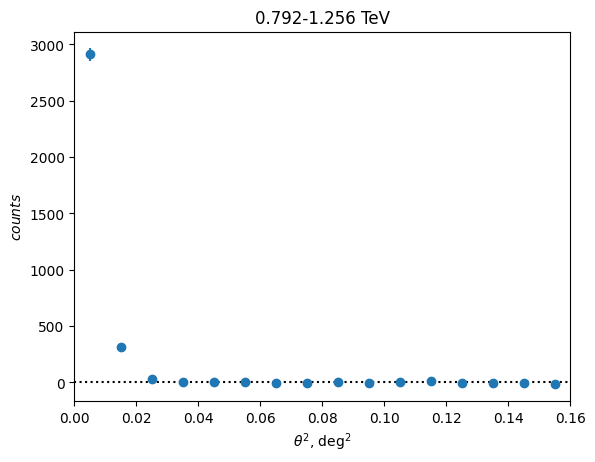

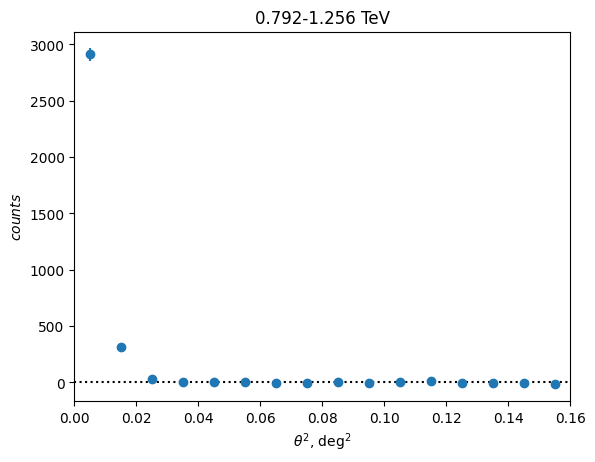

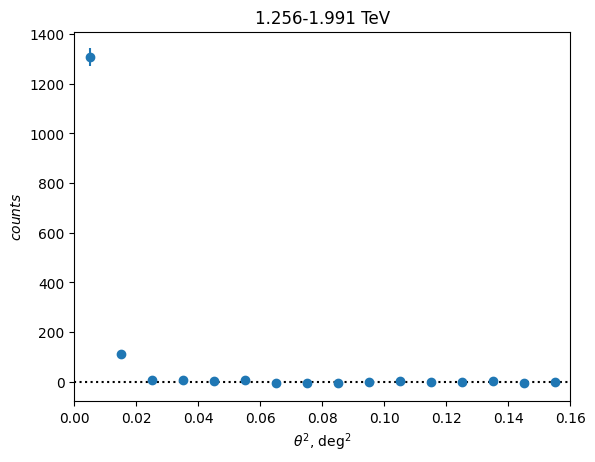

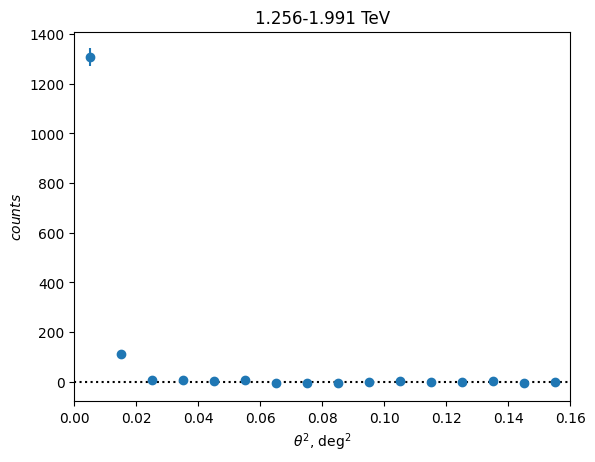

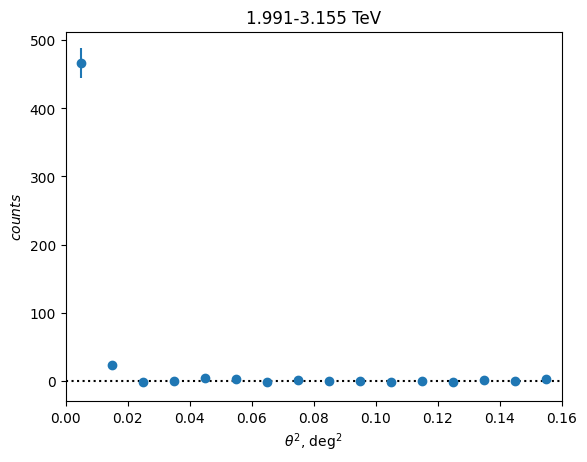

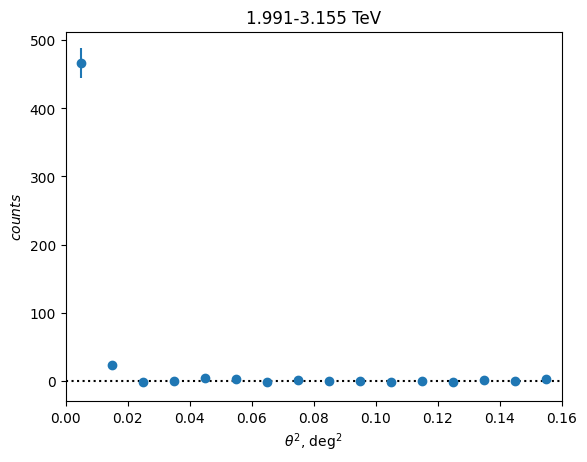

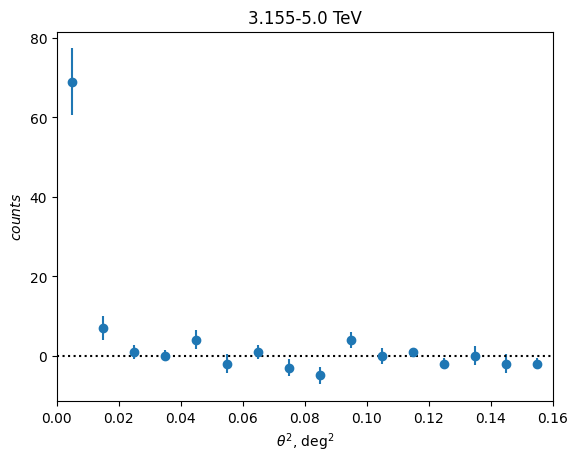

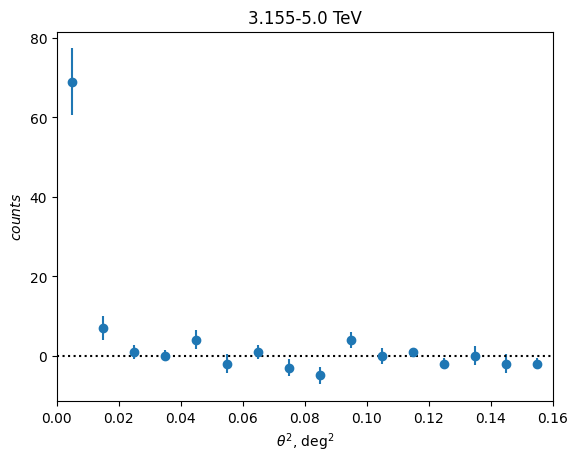

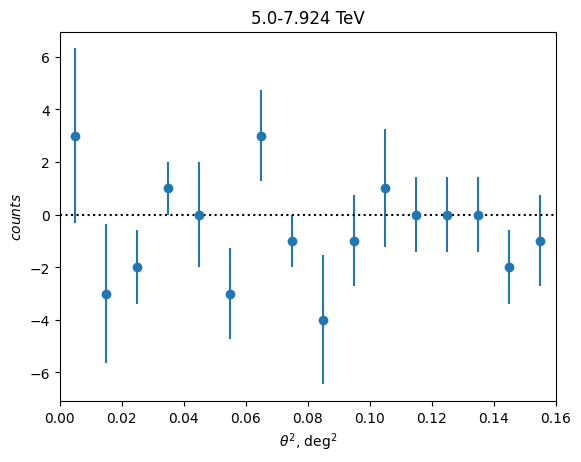

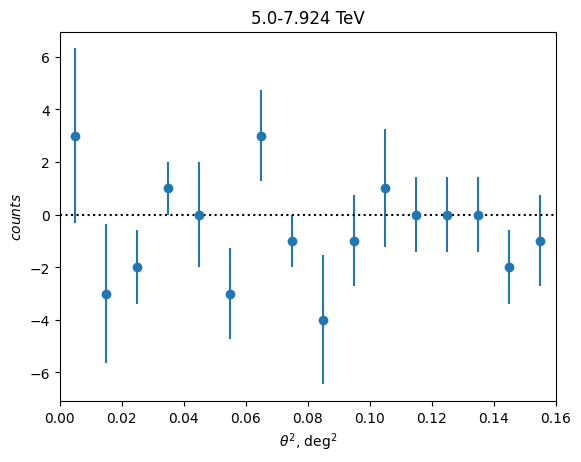

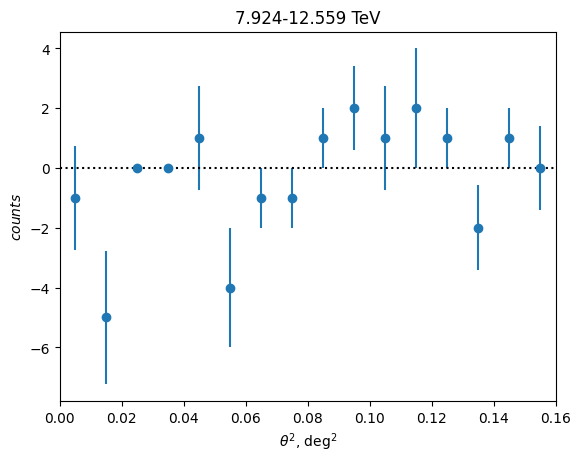

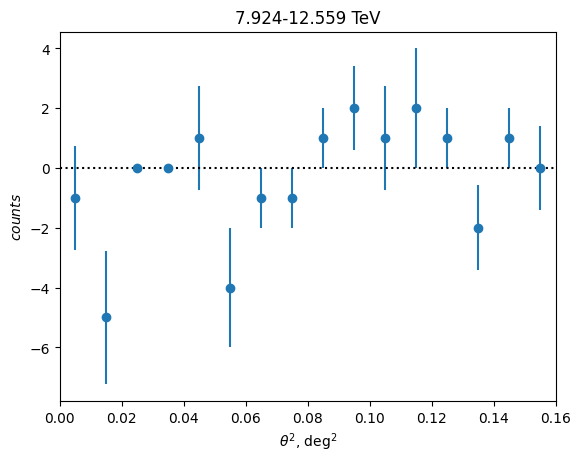

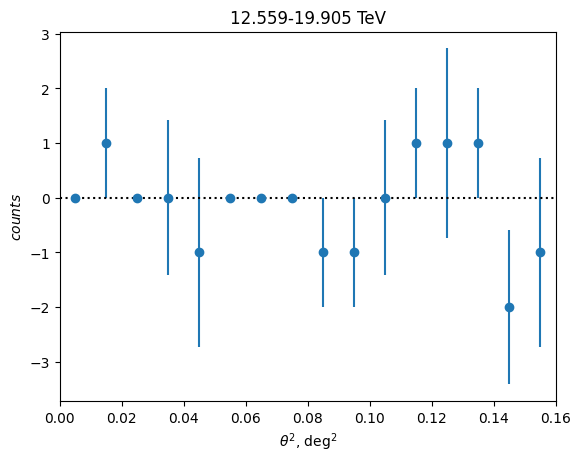

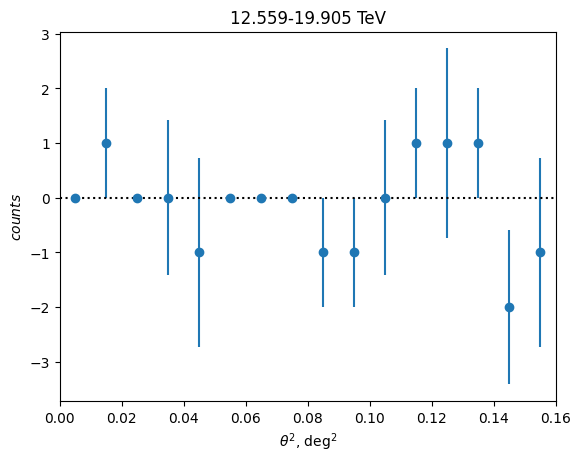

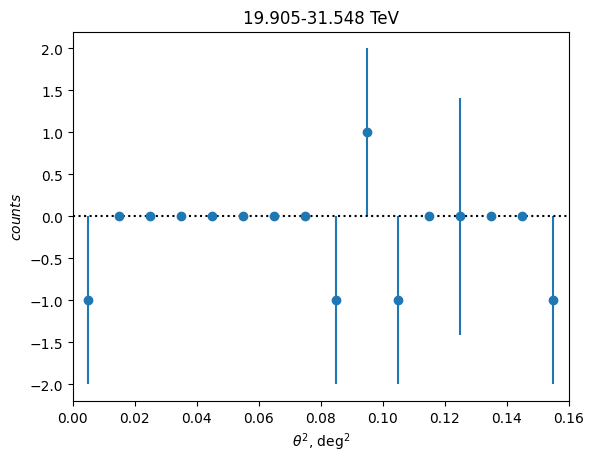

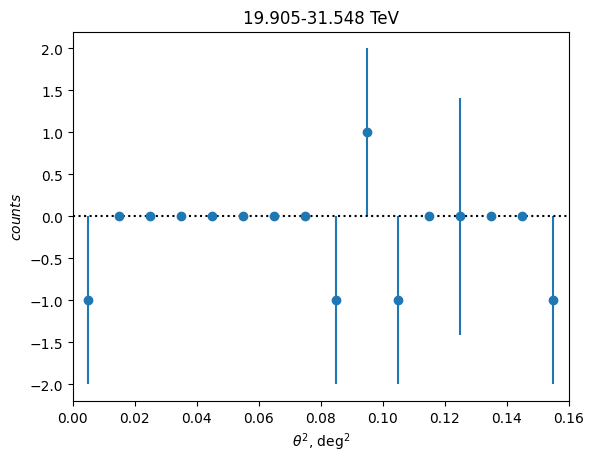

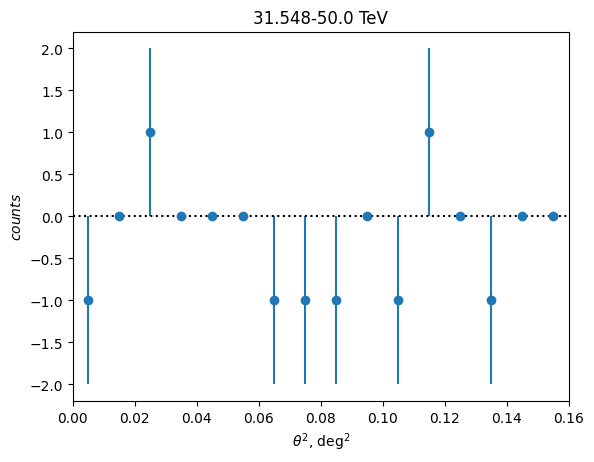

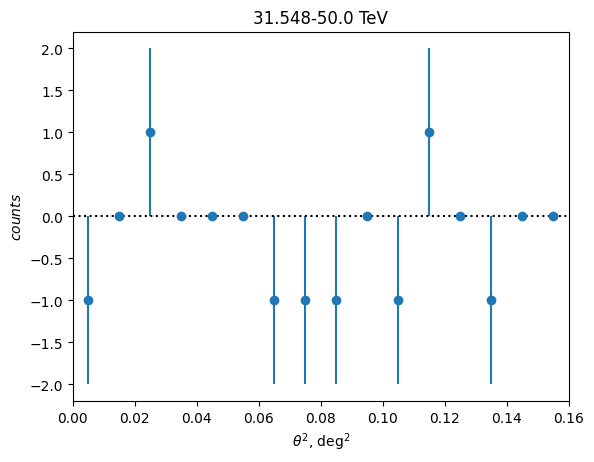

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)


for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
psf_hbu = irf["psf"]
print(psf_hbu)
print(psf_hbu.info())
print(psf_hbu.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

converged at 
786
2.762867128776879
converged at 
723
2.7257376568683114
converged at 
683
2.756022290272096
converged at 
663
2.765275736135493


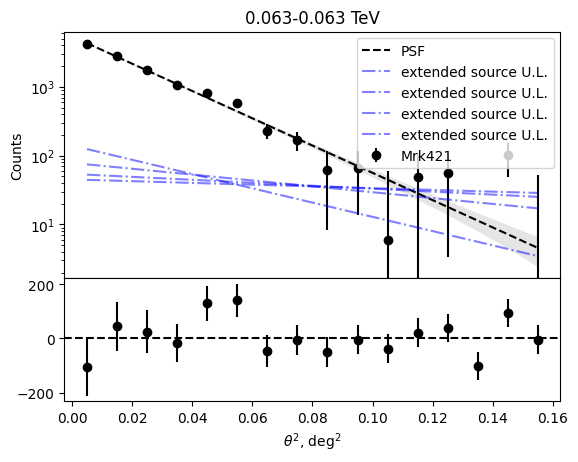

converged at 
842
2.8230095898253893
converged at 
798
2.7716790796918858
converged at 
766
3.02230075974731
converged at 
749
2.9247931497666144


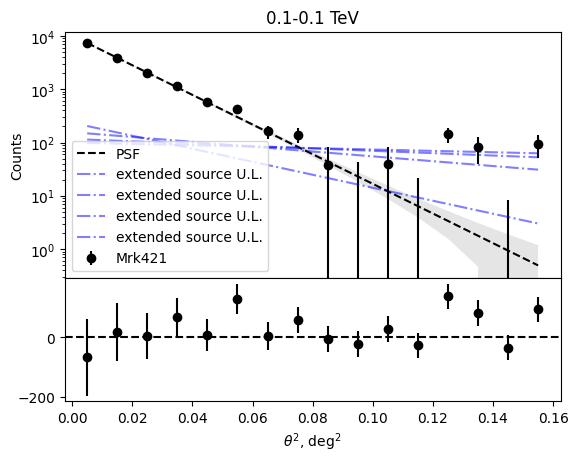

converged at 
701
2.723613631068737
converged at 
611
2.7279765942250584
converged at 
580
2.7156075806169113
converged at 
567
2.747479500000967


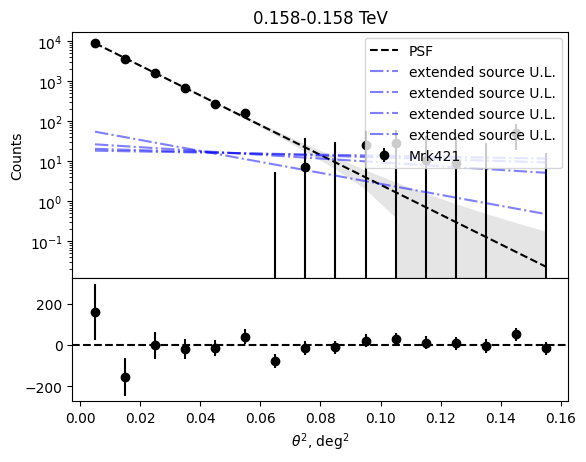

converged at 
684
2.7135739765350415
converged at 
564
2.7373950118454715
converged at 
521
2.74090252122301
converged at 
503
2.7454763922896106


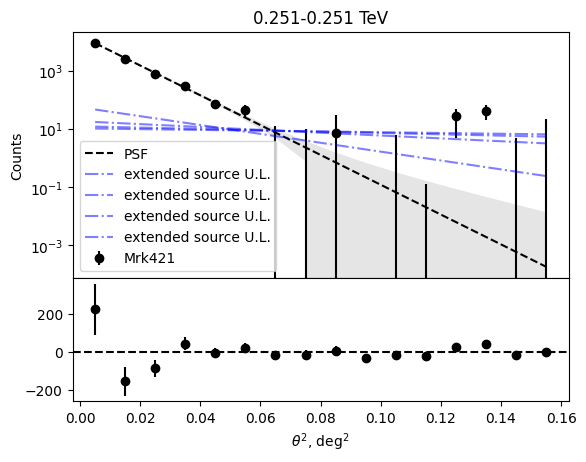

converged at 
604
2.7166114128104226
converged at 
520
2.711213970037292
converged at 
499
2.7332291136196005
converged at 
488
2.7105840777664945


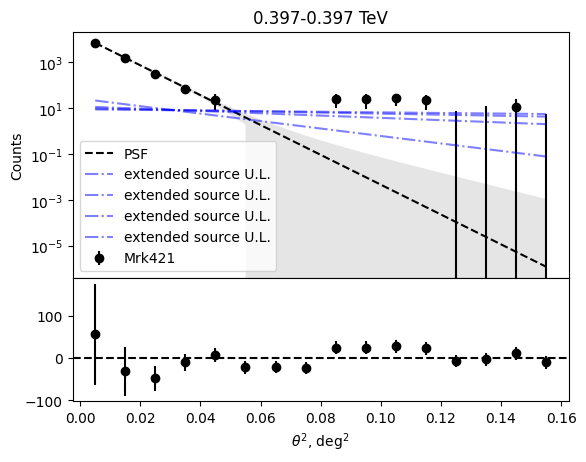

converged at 
545
2.7234578678252817
converged at 
455
2.711283514015612
converged at 
430
2.721564820000964
converged at 
419
2.729791836639471


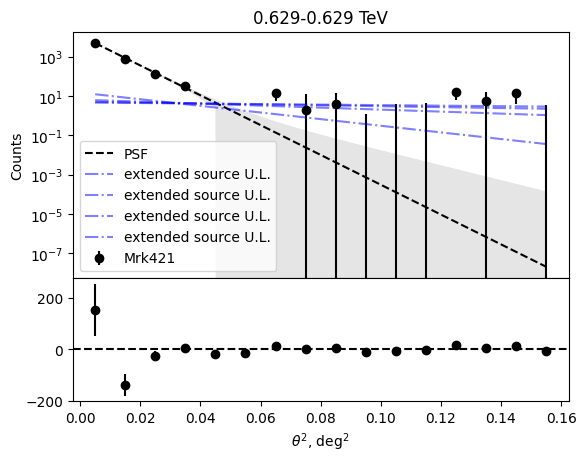

converged at 
526
2.724810696482347
converged at 
389
2.7353536939125114
converged at 
333
2.726760932189407
converged at 
309
2.7197886677407794


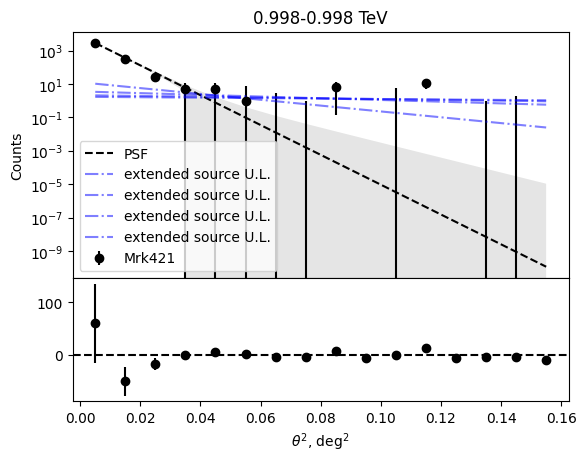

converged at 
516
2.7208133580003437
converged at 
375
2.7139873404499735
converged at 
322
2.7420916272462694
converged at 
299
2.725613706748243


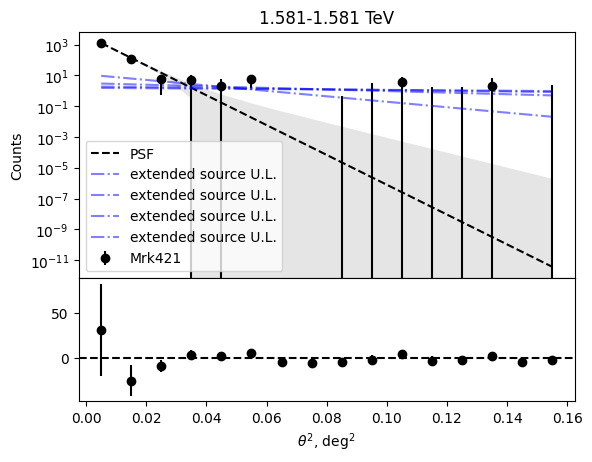

converged at 
406
2.7212168492287105
converged at 
339
2.7354365101238116
converged at 
310
2.7276837002862244
converged at 
296
2.7232620330947768


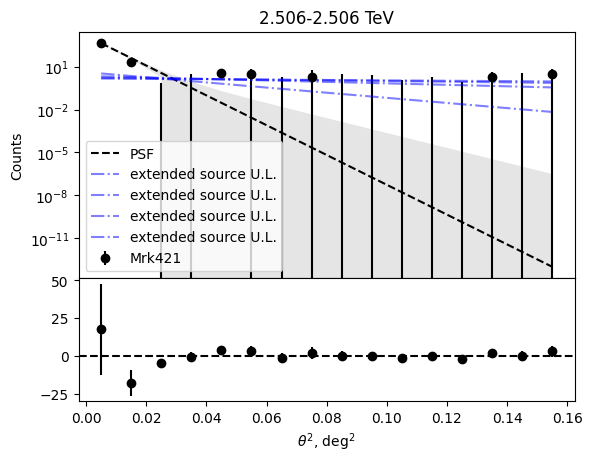

converged at 
462
2.7610588667815854
converged at 
319
2.7566938673261028
converged at 
255
2.7256090965286006
converged at 
227
2.710941949278002


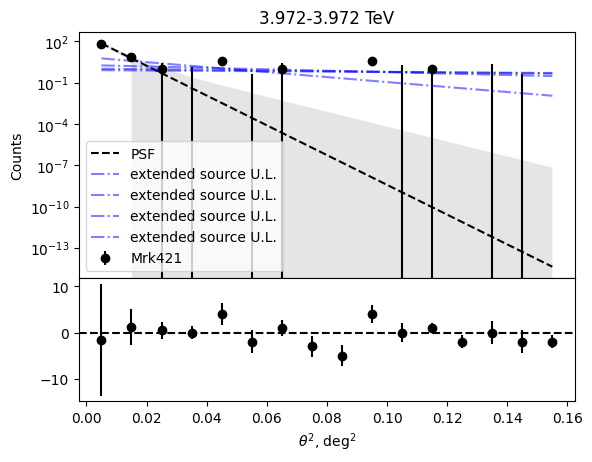

/tmp/ipykernel_900/2422177958.py:26: RuntimeWarning: invalid value encountered in sqrt
  psf_component_err = np.sqrt(psf_component)


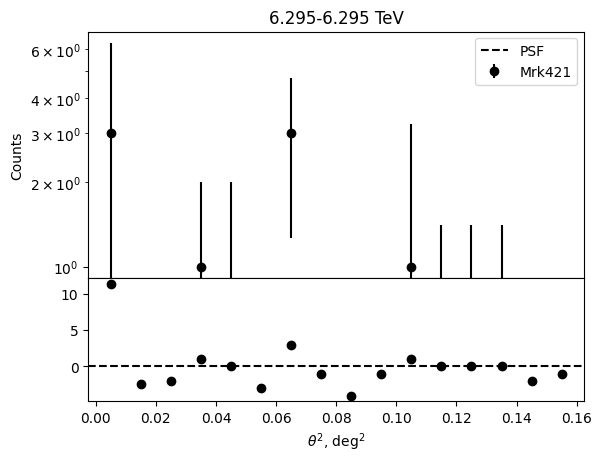

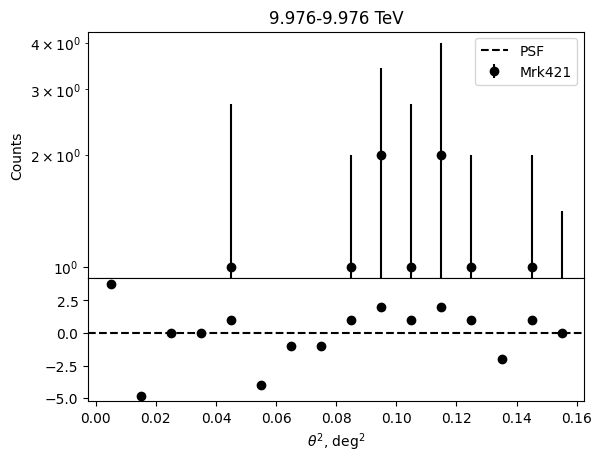

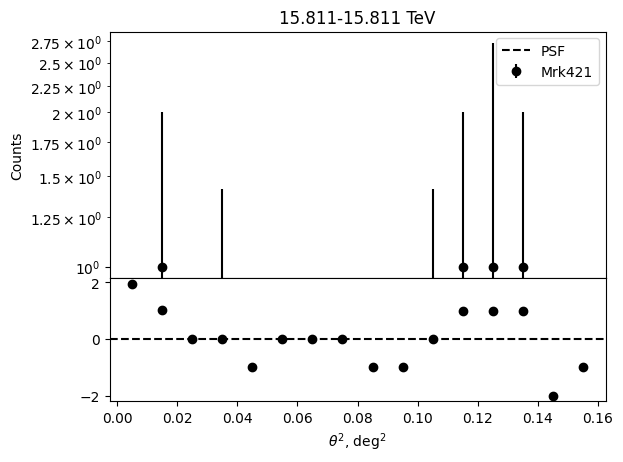

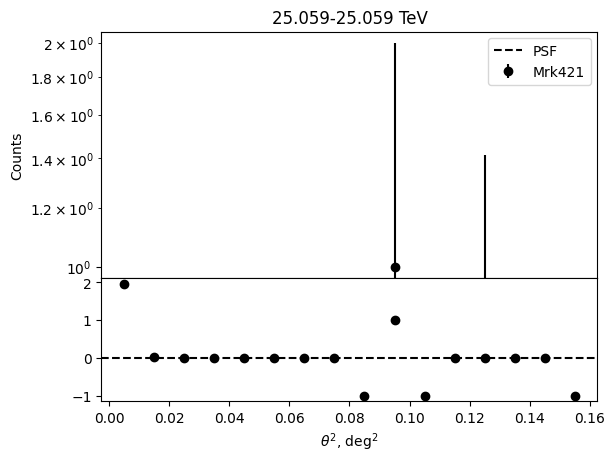

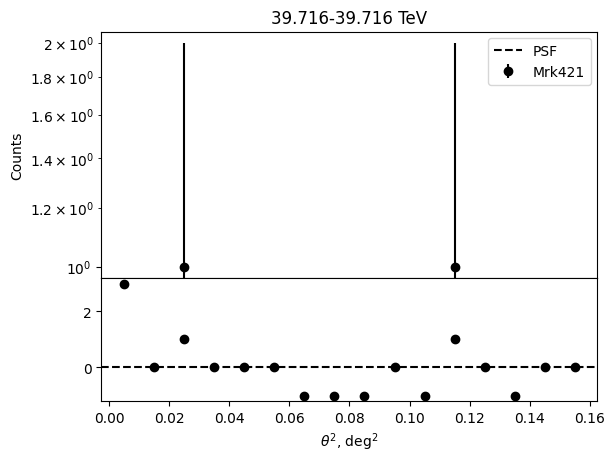

In [8]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.logspace(np.log10(0.1), np.log10(1000), 1000)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the psf component to match total counts of the data
    psf_component *= sum(ct)/sum(psf_component)
    #psf_component_err = ct_err*sum(psf_component)/sum(ct)
    psf_component_err = np.sqrt(psf_component)
    
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
    # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
    # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            # here i renormalize the point source taking away te extended emission counts. (...NOT)
            #no_ext_renormaliz = 1 - np.sum(ct_ext)/np.sum(psf_component)
            #ct_ext_plus_src = ct_ext+psf_component*no_ext_renormaliz
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
                              
            delta_chi2 = chi2_ext - chi2_noext
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/(np.sum(psf_component) + np.sum(ct_ext))
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    axs[0].set_ylabel('Counts')
    axs[0].legend()
    axs[0].set_yscale('log')
    plt.show()

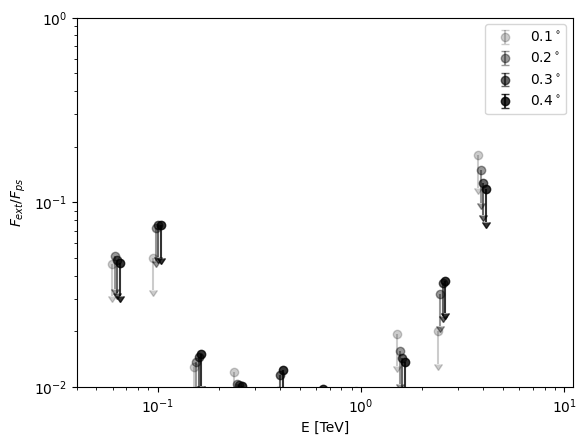

In [9]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()

Here i do the same algorithm as andrii to se if its any different

fraction U.L. 0.17291302038436698
fraction U.L. 0.09416092714619004
fraction U.L. 0.07733143792217394
fraction U.L. 0.07225045656086561
fraction U.L. 0.11370126147217391
fraction U.L. 0.08177456388520869
fraction U.L. 0.07476974037009725
fraction U.L. 0.07224684385753992
fraction U.L. 0.020844217613596085
fraction U.L. 0.019636195885489923
fraction U.L. 0.02023119225701602
fraction U.L. 0.020433504179586174
fraction U.L. 0.014861371474888852
fraction U.L. 0.013861469492338426
fraction U.L. 0.014140085029134416
fraction U.L. 0.014140085029134407
fraction U.L. 0.011025992086967902
fraction U.L. 0.012800834515124983
fraction U.L. 0.014861371474888837
fraction U.L. 0.01577564528616131
fraction U.L. 0.00801924930953922
fraction U.L. 0.010182318703537573
fraction U.L. 0.011821355908490372
fraction U.L. 0.01254860750428867
fraction U.L. 0.011821355908490443
fraction U.L. 0.011247614527915967
fraction U.L. 0.010701719290739223
fraction U.L. 0.010386983309478704
fraction U.L. 0.0225713008164534

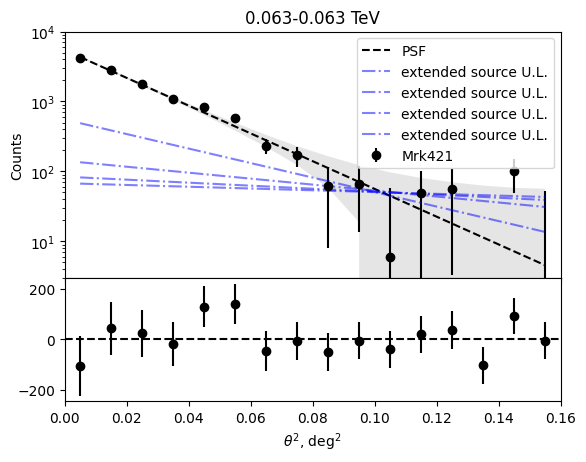

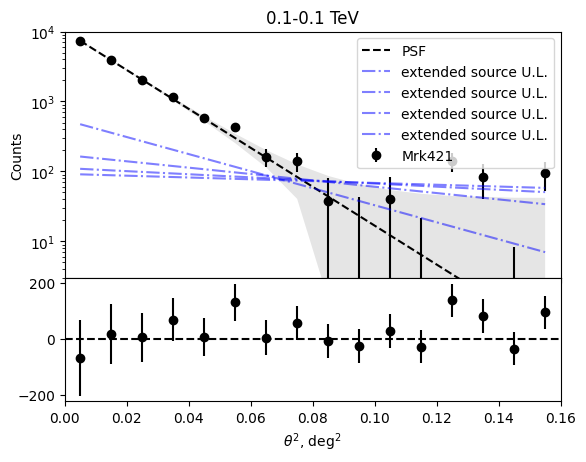

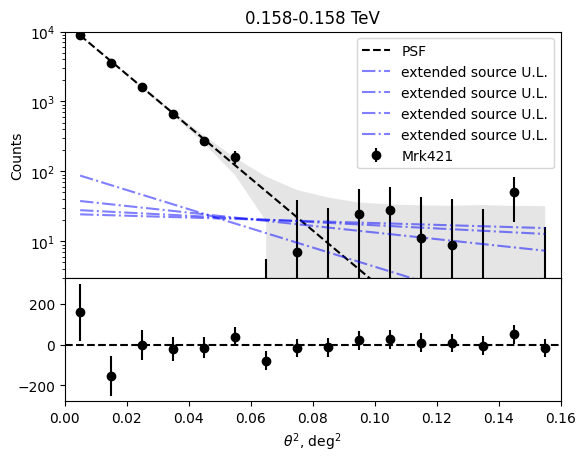

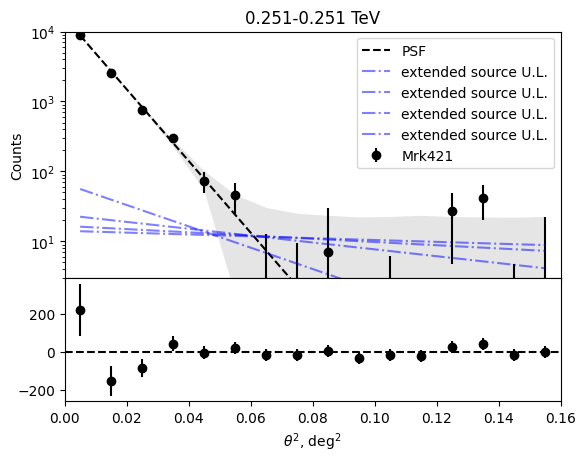

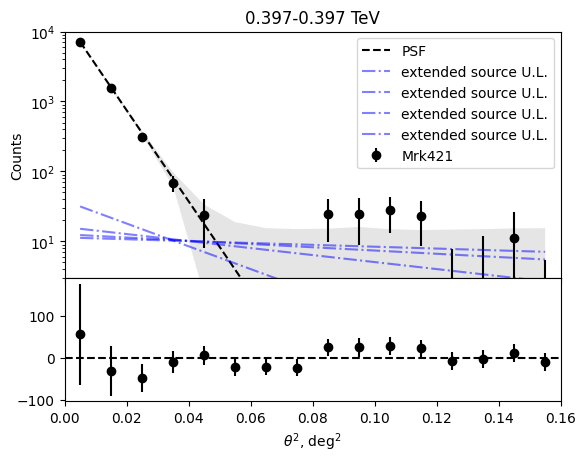

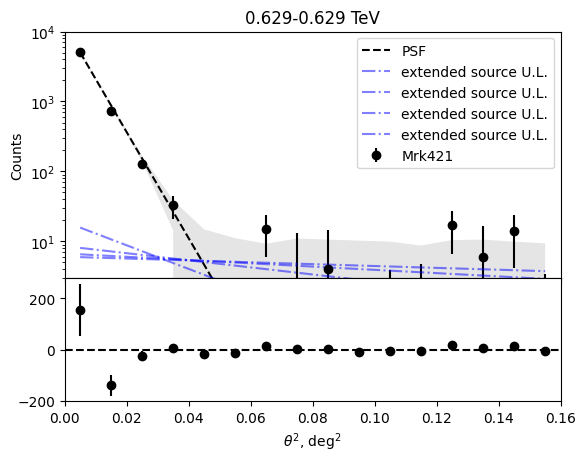

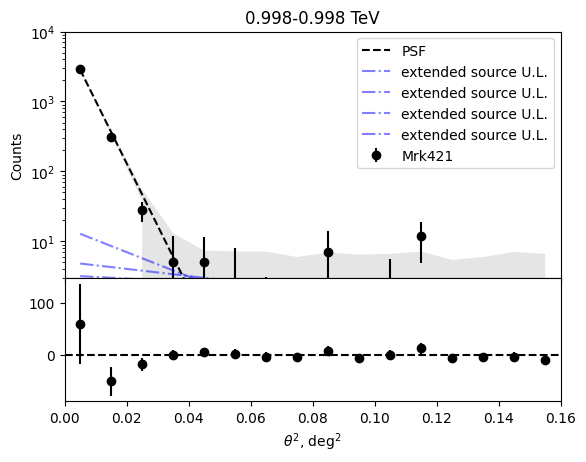

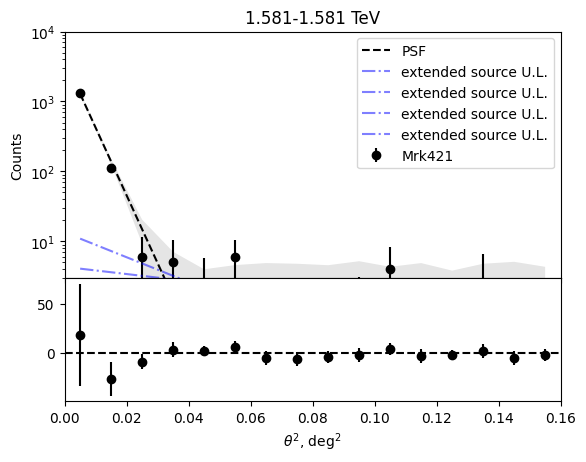

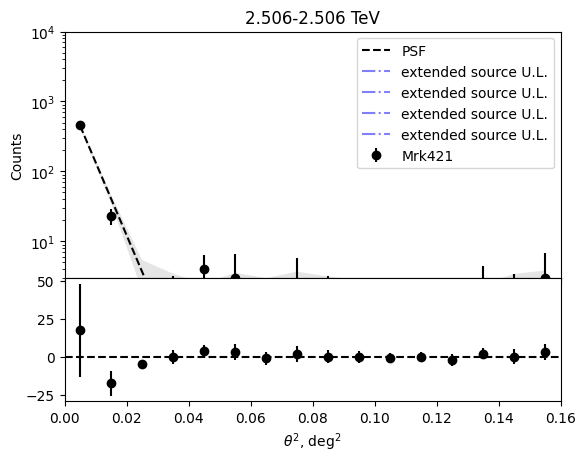

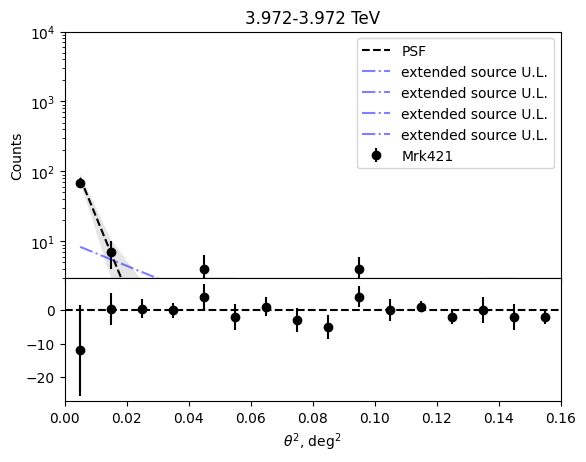

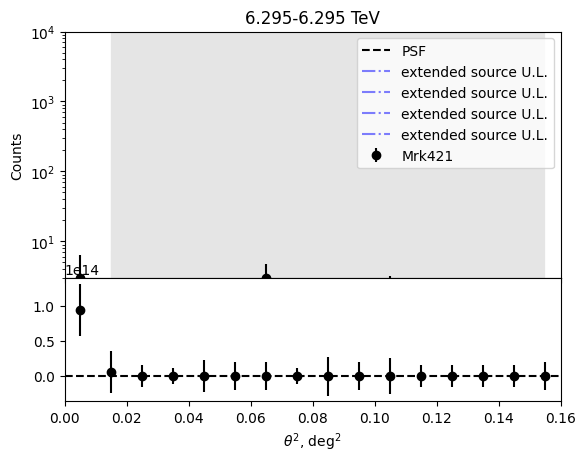

In [10]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
flux_ratios = np.zeros((len(sigmas_ext), len(e)))
chi2max = 2.71

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    if i>10:
        continue
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the psf component to match total counts of the data
    psf_component *= sum(ct)/sum(psf_component)
    psf_component_err = ct_err*sum(psf_component)/sum(ct)
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    for k, sigma_ext in enumerate(sigmas_ext):
        def ext_model(th2):
            sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
            sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
            sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
            gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
            gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
            gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
            return (gauss1_conv + gauss2_conv + gauss3_conv)

        ct_ext = ext_model(th2)
        ct_ext*=sum(ct)/sum(ct_ext)
        chisq=sum((ct-psf_component-ct_ext)**2/(ct_err**2+psf_component_err**2))

        step=1.01
        chisq_best=1e10
        adjust=1.
        adjust1=1.

        while(chisq<chisq_best):
            chisq_best=chisq
            chisq0=sum((ct-step*adjust*psf_component-adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step-adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq2=sum((ct-adjust*psf_component-step*adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq3=sum((ct-adjust*psf_component-adjust1*ct_ext/step)**2/(ct_err**2+(psf_component_err)**2))
            chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
            chisq=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            if(chisq<chisq_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                if(ind==2):
                    adjust1*=step
                if(ind==3):
                    adjust1/=step
        tot_ct_ext=sum(adjust1*ct_ext)

        #Calculation of Upper limit on extended emission
        model_ps=adjust*psf_component
        model_err = psf_component_err
        model_ext=adjust1*ct_ext
        adjust=1.
        adjust1=1.
        chisq_lim=chisq_best
        while(chisq_lim<chisq_best+chi2max):
            chisq_best1=1e10
            adjust1*=step
            chisq=sum((ct-adjust*model_ps-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
            while(chisq<chisq_best1):
                chisq_best1=chisq
                chisq0=sum((ct-step*adjust*model_ps-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
                chisq1=sum((ct-adjust*model_ps/step-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
                chisq_vec=np.array([chisq0,chisq1])
                chisq=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                if(chisq<chisq_best1):
                    if(ind==0):
                        adjust*=step
                    if(ind==1):
                        adjust/=step
            #print('..',adjust,adjust1,adjust1*cts_ext,adjust*cts_point,chisq_lim)
            chisq_lim=chisq_best1
        axs[0].plot(th2,adjust1*model_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
        ext_ul=sum(adjust1*model_ext)
        print('fraction U.L.',ext_ul/(np.sum(psf_component)+tot_ct_ext))
        flux_ratios[k,i]=ext_ul/(np.sum(psf_component)+tot_ct_ext)
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].set_yscale('log')
        axs[0].set_ylim(3e0,1e4)
        axs[0].legend(loc='upper right')
        plt.xlim(0,0.16)

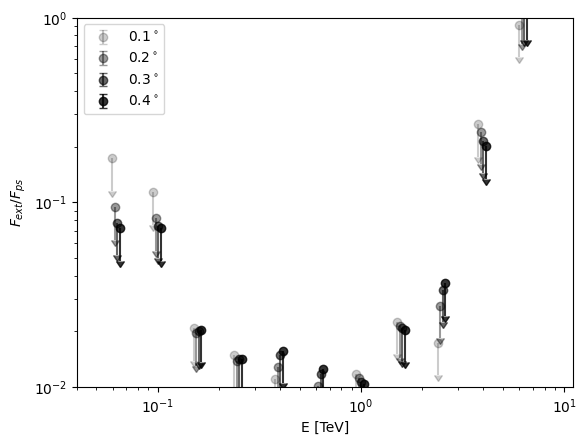

In [11]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()

converged at 
626
2.7618835630029697
converged at 
593
2.722240112336438
converged at 
570
2.7605470875764446
converged at 
557
2.720676648424055


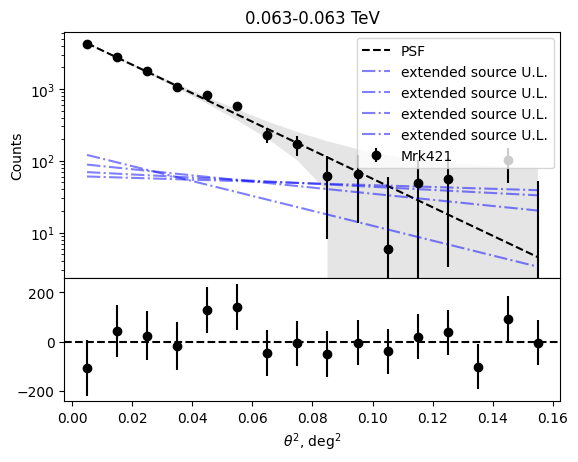

converged at 
654
2.7734132615331912
converged at 
633
2.8208363540998516
converged at 
615
2.7272904775023914
converged at 
606
2.8305464353431162


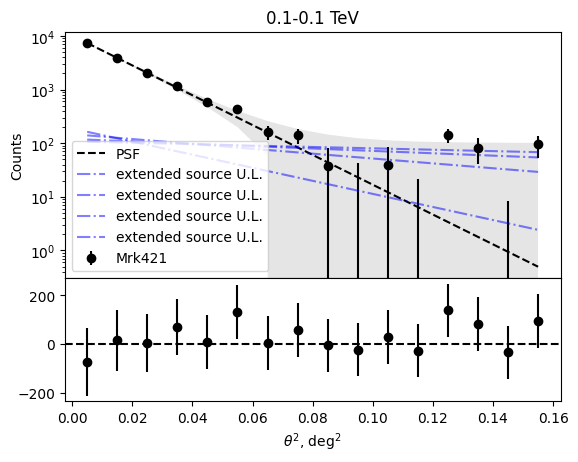

converged at 
653
2.7367289636363794
converged at 
597
2.7587812702675465
converged at 
572
2.746897172039677
converged at 
560
2.7281203629770565


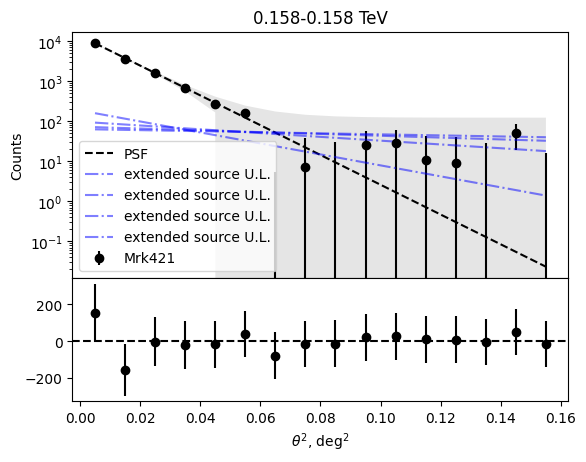

converged at 
677
2.742539402832109
converged at 
614
2.746690623017648
converged at 
586
2.7185206628789578
converged at 
574
2.7633686551263805


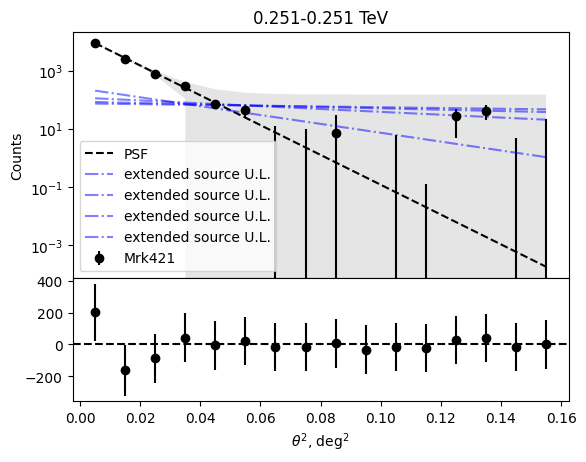

converged at 
681
2.759640670790734
converged at 
623
2.7232685192707065
converged at 
597
2.7173990255203
converged at 
585
2.7344114183192474


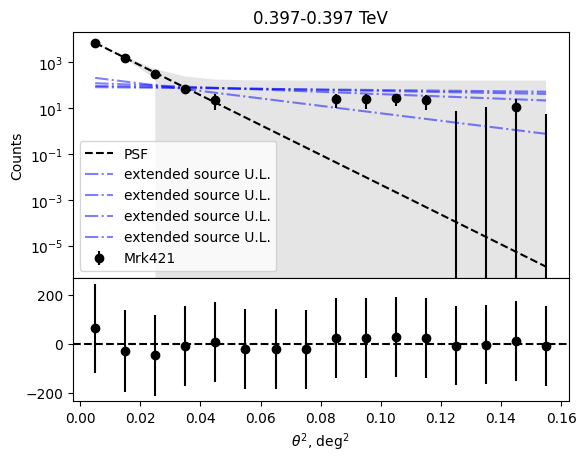

converged at 
687
2.7423891633358854
converged at 
623
2.7657100742758622
converged at 
595
2.7469212632977618
converged at 
582
2.7380777554527205


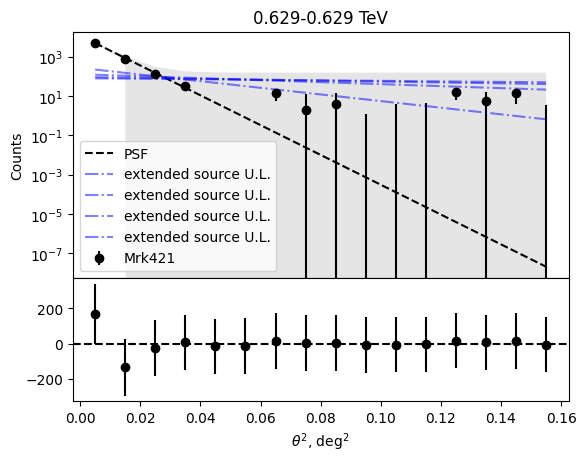

converged at 
673
2.7631060149397926
converged at 
612
2.7341579773377305
converged at 
584
2.738635476231343
converged at 
571
2.7501542620757222


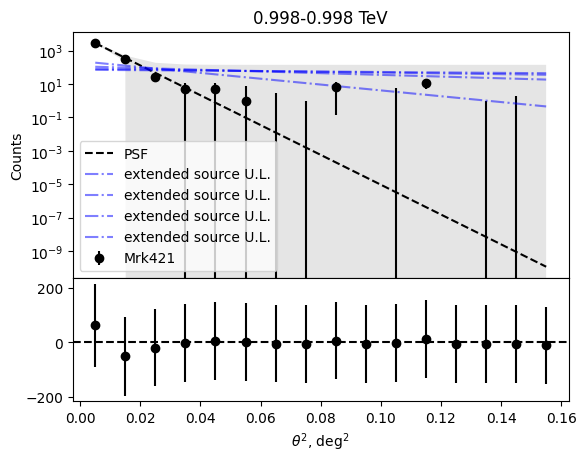

converged at 
646
2.768663943504486
converged at 
586
2.7228000605182565
converged at 
558
2.716225885871248
converged at 
545
2.7233937739347525


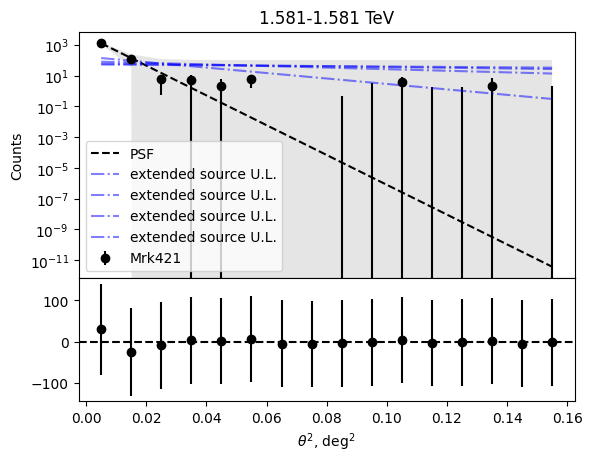

converged at 
614
2.774967327331986
converged at 
554
2.741073762096917
converged at 
526
2.730287907740668
converged at 
513
2.737996734733271


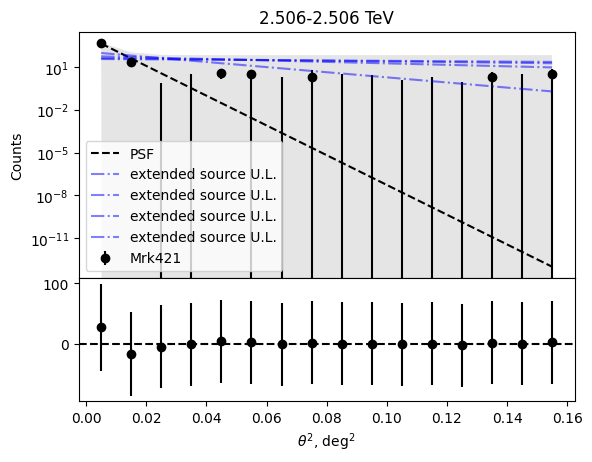

converged at 
530
2.7149529097079124
converged at 
474
2.7582676963156203
converged at 
446
2.761347203636598
converged at 
432
2.7171871237934755


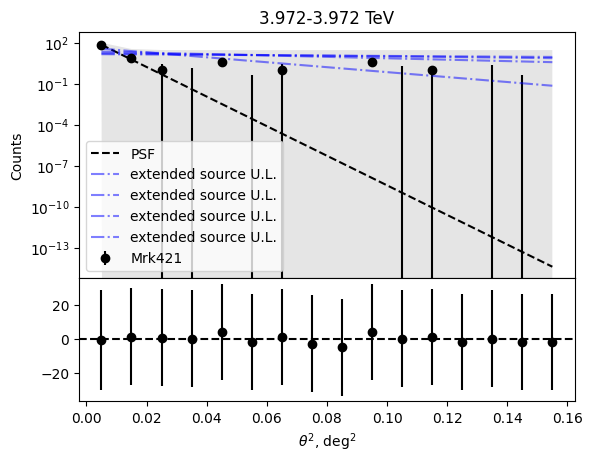

converged at 
452
2.730863579471935
converged at 
393
2.739499783528814
converged at 
365
2.7154985325696694
converged at 
353
2.7645348326379833


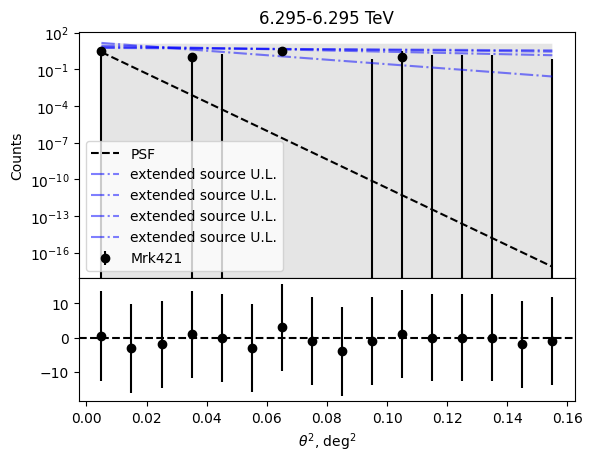

/layers/paketo-buildpacks_conda-env-update/conda-env/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_900/2134241847.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_point, pcov_point = curve_fit(


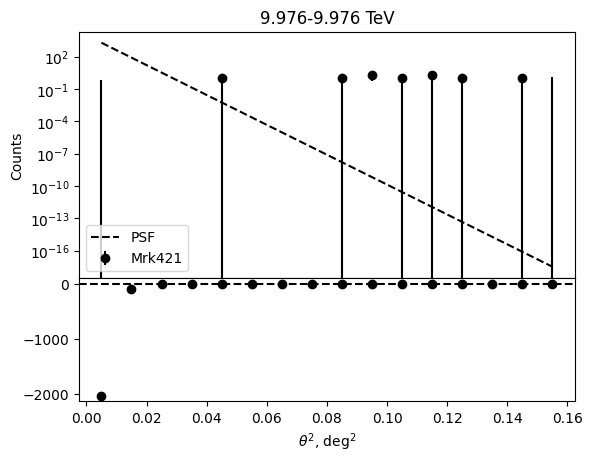

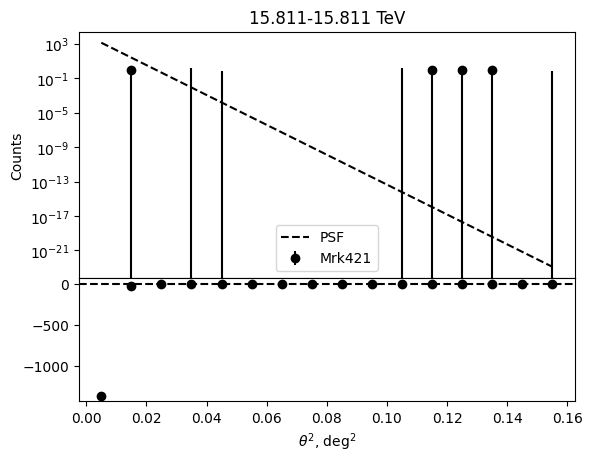

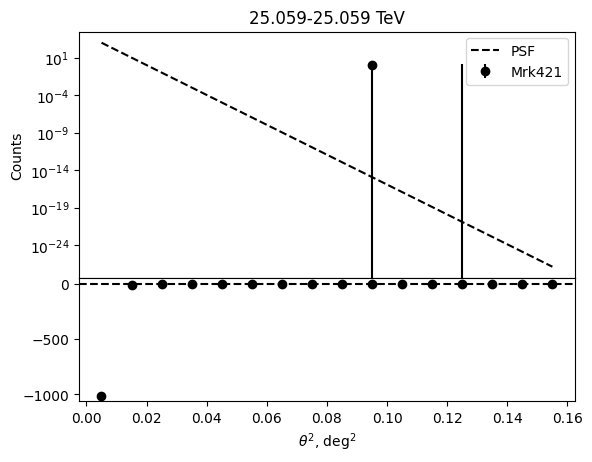

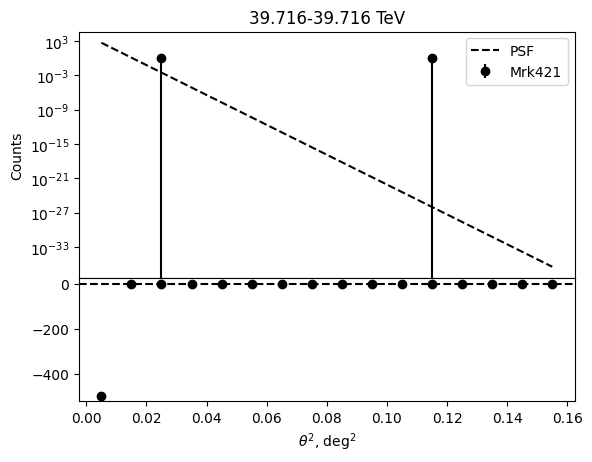

In [12]:
# A modo mio
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.logspace(np.log10(0.1), np.log10(10000), 1000)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = np.argmin(np.abs(psf_e_means - e[i]))
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2, norm):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return norm*(gauss1+gauss2+gauss3)

    init_guess = [10000]
    popt_point, pcov_point = curve_fit(
        psf_model,
        th2,
        ct,
        sigma=ct_err,
        p0 = init_guess,
        absolute_sigma=True
    )
    
    ct_point = psf_model(th2, popt_point)
    ct_point_err = np.sqrt(np.diag(pcov_point))
    chi2_point = np.sum(((ct - ct_point)**2 / (ct_err**2 + ct_point_err**2)))
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,ct_point,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(ct_point-ct_point_err),(ct_point+ct_point_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - ct_point,np.sqrt(ct_err**2+ct_point_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
    # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
    # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            ct_point_and_ext = ct_ext+ct_point
            chi2_point_and_ext = np.sum(((ct - ct_point_and_ext)**2 / (ct_err**2 + ct_point_err**2)))             
            delta_chi2 = chi2_point_and_ext - chi2_point
            
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/(np.sum(ct_point) + np.sum(ct_ext))
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    axs[0].set_ylabel('Counts')
    axs[0].legend()
    axs[0].set_yscale('log')
    plt.show()

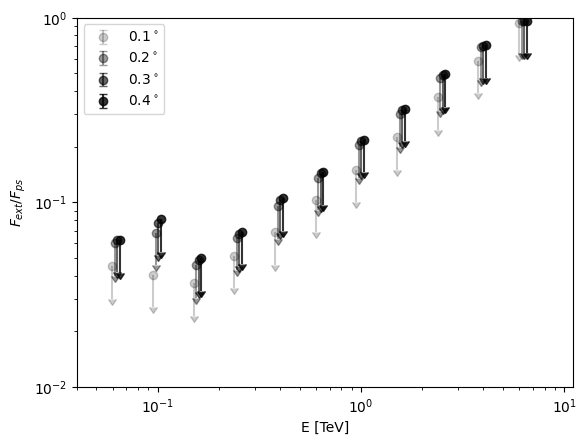

In [13]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()